Determining the size of the dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/train.csv")
df.shape


(2930, 82)

In [6]:
# First 5 rows
df.head()


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Identifying perfect coloumns and missing data


In [7]:
# Data info: column types, null counts. Shows us the "perfect" column
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [8]:
# Quick summary statistics for numerical columns
df.describe()


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


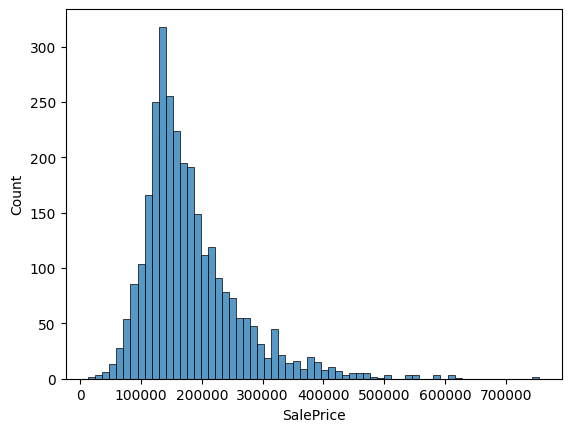

In [9]:
# This creates a 'distribution plot' of the SalePrice
sns.histplot(df['SalePrice'])
plt.show()

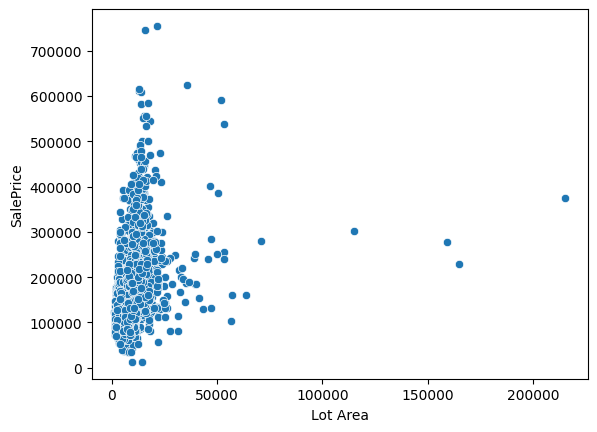

In [10]:
#Does a bigger lot mean a higher price? Let's see with a scatter plot
sns.scatterplot(x='Lot Area', y='SalePrice', data=df)
plt.show()

In [ ]:
# This calculates the correlation of all numbers with SalePrice
# and sorts them so the strongest correlations are at the top.
correlation_series = df.select_dtypes(include=['number']).corr()['SalePrice'].sort_values(ascending=False)
print(correlation_series.head(10))

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Name: SalePrice, dtype: float64


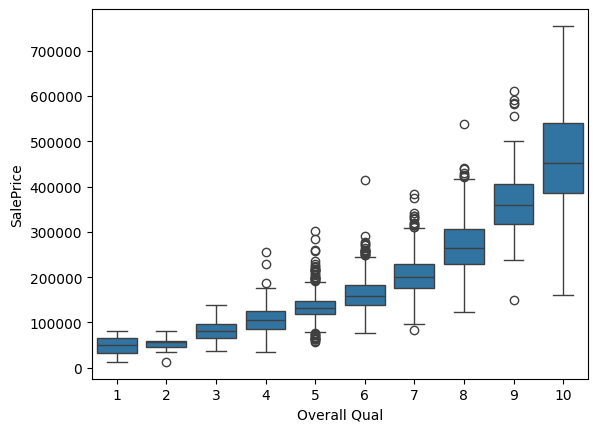

In [12]:
#Overall quality has the highest correlation with SalePrice. Let's see how they relate with a boxplot.
sns.boxplot(x='Overall Qual', y='SalePrice', data=df)
plt.show()

Identifying colums with missing data and the percentage

In [13]:
# This calculates the percentage of missing data for every column
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
null_report = pd.concat([missing_data, missing_percent], axis=1, keys=['Total', 'Percent'])

# Show only the columns that actually have missing values, sorted by the worst first
print(null_report[null_report['Total'] > 0].sort_values(by='Total', ascending=False).head(20))

                Total    Percent
Pool QC          2917  99.556314
Misc Feature     2824  96.382253
Alley            2732  93.242321
Fence            2358  80.477816
Mas Vnr Type     1775  60.580205
Fireplace Qu     1422  48.532423
Lot Frontage      490  16.723549
Garage Qual       159   5.426621
Garage Cond       159   5.426621
Garage Yr Blt     159   5.426621
Garage Finish     159   5.426621
Garage Type       157   5.358362
Bsmt Exposure      83   2.832765
BsmtFin Type 2     81   2.764505
Bsmt Cond          80   2.730375
Bsmt Qual          80   2.730375
BsmtFin Type 1     80   2.730375
Mas Vnr Area       23   0.784983
Bsmt Full Bath      2   0.068259
Bsmt Half Bath      2   0.068259


Deleting data that wont assist in predicting sales price

In [14]:
# Create a list of columns to delete
cols_to_drop = ['PID', 'Order', 'Misc Feature', 'Alley']

# Drop them from our dataframe
df = df.drop(cols_to_drop, axis=1)

# Check the new shape to confirm they are gone
print(f"New Shape: {df.shape}")

New Shape: (2930, 78)


Filling in missing data (categorical data) 

In [15]:
# List of columns where 'NaN' actually means 'None' (per the data description)
none_cols = ['Pool QC', 'Garage Qual', 'Garage Cond', 'Garage Type', 
             'Fireplace Qu', 'Bsmt Qual', 'Bsmt Cond', 'Fence']

# Loop through and fill them with the word "None"
for col in none_cols:
    df[col] = df[col].fillna('None')

# Verify it worked for one of them
print(df['Pool QC'].value_counts())

Pool QC
None    2917
Ex         4
Gd         4
TA         3
Fa         2
Name: count, dtype: int64


In [16]:
# The 'transform' function applies the median of each group to the holes in that group
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))

# Now check if we have any holes left in Lot Frontage
print(f"Missing Lot Frontage: {df['Lot Frontage'].isnull().sum()}")

Missing Lot Frontage: 3


In [17]:
# 1. Fix those 3  Lot Frontage houses with the overall median
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

# 2. For other numeric columns (Mas Vnr Area, etc.), fill with 0 
# (Because if it's missing, the house likely doesn't have that feature)
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# 3. FINAL CHECK: Are there any null values left?
print(df.isnull().sum().sum())

2179


In [18]:
# This catches every remaining TEXT column and fills it with "None" or "Standard"
object_cols = df.select_dtypes(include=['object']).columns
df[object_cols] = df[object_cols].fillna('None')

# NOW check the total again
print(f"Total missing values: {df.isnull().sum().sum()}")

Total missing values: 0


C:\Users\Pfunz\AppData\Local\Temp\ipykernel_20444\2067692756.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include=['object']).columns


In [19]:
# 1. Total Square Footage
df['Total_SF'] = df['1st Flr SF'] + df['2nd Flr SF'] + df['Total Bsmt SF']

# 2. Total Bathrooms (Counting half-baths as 0.5)
df['Total_Bath'] = df['Full Bath'] + (0.5 * df['Half Bath']) + df['Bsmt Full Bath'] + (0.5 * df['Bsmt Half Bath'])

# 3. Drop the 'Old' redundant columns to keep the data lean
cols_to_drop = ['Yr Sold', 'Year Built', '1st Flr SF', '2nd Flr SF', 'Total Bsmt SF', 
                'Full Bath', 'Half Bath', 'Bsmt Full Bath', 'Bsmt Half Bath']

df = df.drop(cols_to_drop, axis=1)

print(f"New Feature Count: {df.shape[1]}")

New Feature Count: 71


In [ ]:
# Transforms ALL text columns into 1s and 0s so model can understand them. drop_first=True avoids the dummy variable trap.
df_final = pd.get_dummies(df, drop_first=True)

# Let's see how many columns we have now
print(f"Columns before: {df.shape[1]}")
print(f"Columns after: {df_final.shape[1]}")
print(df_final.head())

Columns before: 71
Columns after: 263
   MS SubClass  Lot Frontage  Lot Area  Overall Qual  Overall Cond  \
0           20         141.0     31770             6             5   
1           20          80.0     11622             5             6   
2           20          81.0     14267             6             6   
3           20          93.0     11160             7             5   
4           60          74.0     13830             5             5   

   Year Remod/Add  Mas Vnr Area  BsmtFin SF 1  BsmtFin SF 2  Bsmt Unf SF  ...  \
0            1960         112.0         639.0           0.0        441.0  ...   
1            1961           0.0         468.0         144.0        270.0  ...   
2            1958         108.0         923.0           0.0        406.0  ...   
3            1968           0.0        1065.0           0.0       1045.0  ...   
4            1998           0.0         791.0           0.0        137.0  ...   

   Sale Type_ConLw  Sale Type_New  Sale Type_Oth  Sale

Split the sales price from features.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separate the Sales price from the Features
y = df_final['SalePrice']

# 2. Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (2344, 262)
Testing set size: (586, 262)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Standard Scaling
# This puts all 262 features on the same scale (usually between -3 and 3).
# We 'fit' on the training data ONLY, so the AI doesn't know the 'future' averages of the test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. THE BRAIN: Initialize the Model
# Linear Regression is the standard 'first attempt' for predicting house prices.
model = LinearRegression()

# 3. THE STUDY SESSION: Training
# We give the model the scaled clues (X) and the real prices (y).
# The AI is now finding the 'math formula' for a house price.
model.fit(X_train_scaled, y_train)

# 4. THE PREDICTION: Making guesses
# We give the AI the 'Final Exam' (X_test) and let it guess the prices.
predictions = model.predict(X_test_scaled)

# 5. THE SCORE: 
# MAE tells us how many dollars off the AI was on average.
mae = mean_absolute_error(y_test, predictions)
# R2 score tells us how much of the price variance we 'explained' (0 to 1 scale).
r2 = r2_score(y_test, predictions)

print(f"Average Error: ${mae:.2f}")
print(f"Accuracy Score (R2): {r2:.4f}")

Average Error: $16443.76
Accuracy Score (R2): 0.8955


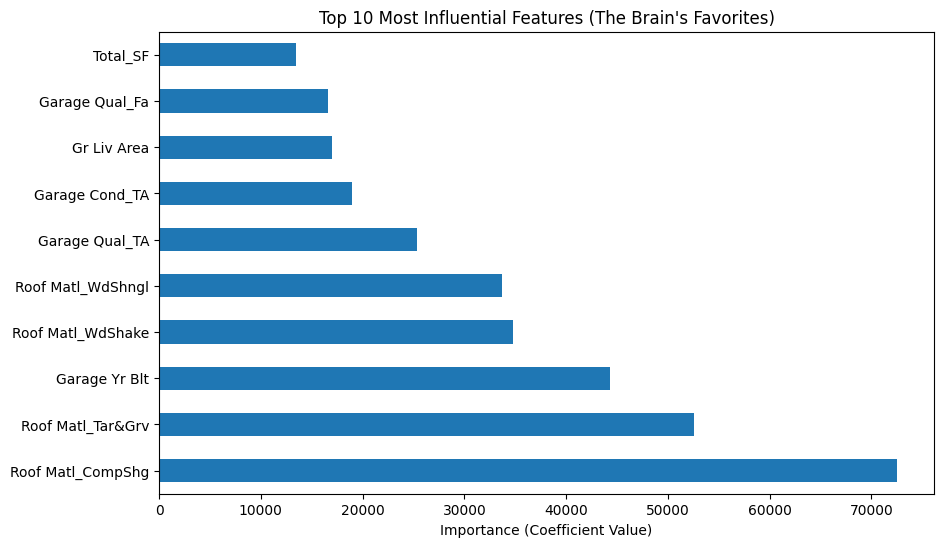

Roof Matl_CompShg    72528.936981
Roof Matl_Tar&Grv    52551.319965
Garage Yr Blt        44270.667052
Roof Matl_WdShake    34752.476934
Roof Matl_WdShngl    33742.579523
Garage Qual_TA       25332.995868
Garage Cond_TA       18940.812385
Gr Liv Area          16951.315973
Garage Qual_Fa       16604.705896
Total_SF             13480.849044
dtype: float64


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the 'Weights' (Coefficients) from the model
# This tells us how much each feature pushes the price up or down
coefficients = pd.Series(model.coef_, index=X.columns)

# 2. Pick the top 10 most influential features
top_10_features = coefficients.abs().sort_values(ascending=False).head(10)

# 3. Visualize it
plt.figure(figsize=(10,6))
top_10_features.plot(kind='barh')
plt.title("Top 10 Most Influential Features (The Brain's Favorites)")
plt.xlabel("Importance (Coefficient Value)")
plt.show()

print(top_10_features)

In [24]:
from sklearn.linear_model import Lasso

# 1. Initialize Lasso (The model with a 'noise filter')
# alpha=100 is like the 'strength' of the filter.
lasso_model = Lasso(alpha=100)

# 2. Train the cleaner model
lasso_model.fit(X_train_scaled, y_train)

# 3. Get new coefficients
lasso_coeffs = pd.Series(lasso_model.coef_, index=X.columns)
lasso_top_10 = lasso_coeffs.abs().sort_values(ascending=False).head(10)

# 4. Check the new top features
print("--- NEW TOP FEATURES (LASSO) ---")
print(lasso_top_10)

--- NEW TOP FEATURES (LASSO) ---
Roof Matl_CompShg    46999.351719
Roof Matl_Tar&Grv    33186.877322
Roof Matl_WdShngl    23550.675452
Roof Matl_WdShake    22148.524588
Gr Liv Area          18022.166647
Kitchen Qual_TA      12915.620639
Kitchen Qual_Gd      11565.976382
Overall Qual         11355.038214
Total_SF              9578.684573
Bsmt Qual_TA          8306.759662
dtype: float64


In [25]:
# Let's find the 'Model Breakers'
# Houses with more than 4000 sq ft but priced under $300k are known 'Errors' in this dataset
outliers = df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 300000)]

print(f"Number of outliers found: {len(outliers)}")

# Pro Tip: Drop these specific rows immediately
df = df.drop(outliers.index)

Number of outliers found: 3


In [ ]:
# Drop the 3 outliers that have massive area but low price
df = df.drop(outliers.index, errors='ignore')

# Verify the size (It should be 2927 if it started at 2930)
print(f"New dataframe size: {df.shape}")

New dataframe size: (2927, 71)


In [ ]:
# 1. GROUP RARE ROOFS: If less than 15 houses have it, call it 'Other'
roof_counts = df['Roof Matl'].value_counts()
rare_roofs = roof_counts[roof_counts < 15].index
df['Roof Matl'] = df['Roof Matl'].replace(rare_roofs, 'Other')

# 2. GROUP RARE NEIGHBORHOODS
# If a neighborhood has very few houses, the model can't learn it well.
neigh_counts = df['Neighborhood'].value_counts()
rare_neighs = neigh_counts[neigh_counts < 10].index
df['Neighborhood'] = df['Neighborhood'].replace(rare_neighs, 'Other')

print("Rare categories have been bundled into 'Other'.")

Rare categories have been bundled into 'Other'.


In [29]:
# 1. RE-ENCODE: Convert the new 'Other' categories into 1s and 0s
df_final = pd.get_dummies(df, drop_first=True)

# 2. RE-SPLIT: 80% to learn, 20% to test
X = df_final.drop('SalePrice', axis=1)
y = df_final['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. RE-SCALE: Give every feature an equal 'voice'
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Final Cleaned Shape: {df_final.shape}")

Final Cleaned Shape: (2927, 256)


In [30]:
from sklearn.linear_model import Lasso
import pandas as pd

# 1. INITIALIZE THE MODEL
# We'll keep alpha at 100 for now. This 'Regularization' helps ignore remaining noise.
final_lasso = Lasso(alpha=100)

# 2. TRAIN (FIT)
final_lasso.fit(X_train_scaled, y_train)

# 3. EVALUATE
# Let's see how accurate the 'Honest' model is on the 20% test set
final_preds = final_lasso.predict(X_test_scaled)
final_mae = mean_absolute_error(y_test, final_preds)
final_r2 = r2_score(y_test, final_preds)

# 4. GET THE TRUTH: NEW FEATURE IMPORTANCE
# We extract the math weights to see what the AI is actually thinking now.
coeffs = pd.Series(final_lasso.coef_, index=X.columns)
top_features = coeffs.abs().sort_values(ascending=False).head(10)

print(f"New Average Error: ${final_mae:.2f}")
print(f"New R2 Score: {final_r2:.4f}")
print("\n--- THE BRAIN'S NEW TOP 10 (HONEST VERSION) ---")
print(top_features)

New Average Error: $15270.17
New R2 Score: 0.9255

--- THE BRAIN'S NEW TOP 10 (HONEST VERSION) ---
Gr Liv Area        16103.091806
Total_SF           14891.288157
Overall Qual       11353.667356
Kitchen Qual_TA     9411.216634
Bsmt Qual_Gd        8811.849181
Bsmt Qual_TA        8604.443413
Kitchen Qual_Gd     8182.754214
BsmtFin SF 1        7460.777968
Exter Qual_TA       7270.273496
Exter Qual_Gd       6185.270376
dtype: float64


--- THE AI'S BIGGEST MISTAKES ---
      Actual      Predicted          Error      Abs_Error
2570  235000  433454.954208 -198454.954208  198454.954208
1767  755000  569143.739591  185856.260409  185856.260409
433   582933  423064.755289  159868.244711  159868.244711
44    611657  452415.186847  159241.813153  159241.813153
432   610000  504151.831948  105848.168052  105848.168052


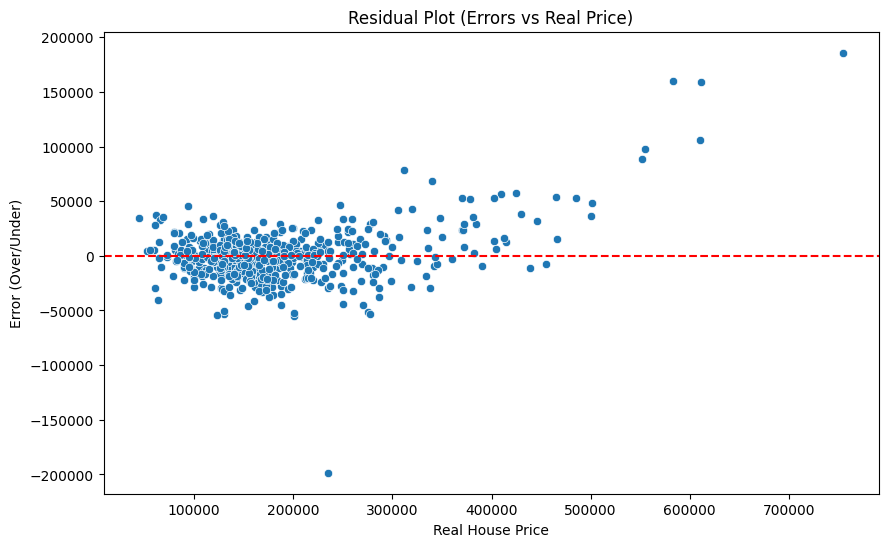

In [31]:
# 1. Calculate the 'Residuals' (Real Price - Predicted Price)
residuals = y_test - final_preds

# 2. Find the Top 5 'Biggest Blunders'
# We use absolute values because being $100k under is just as bad as $100k over.
errors_df = pd.DataFrame({'Actual': y_test, 'Predicted': final_preds, 'Error': residuals})
errors_df['Abs_Error'] = errors_df['Error'].abs()

print("--- THE AI'S BIGGEST MISTAKES ---")
print(errors_df.sort_values(by='Abs_Error', ascending=False).head(5))

# 3. Visualize the 'Residual Plot'
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot (Errors vs Real Price)")
plt.xlabel("Real House Price")
plt.ylabel("Error (Over/Under)")
plt.show()